In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('resources/survey_results.csv')
df.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [3]:
df.shape

(30010, 17)

# Data Cleaning

**Remove Duplicates**

In [4]:
df[df.duplicated()]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
11317,R11312,18,F,Urban,Student,NaN,0-2 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Premium,Medium (Moderately health-conscious),Social (eg. Parties),100-150
19050,R19044,57,M,Semi-Urban,Retired,<10L,3-4 times,Newcomer,Large (1 L),2 to 4,Price,Traditional,Retail Store,Premium,High (Very health-conscious),Social (eg. Parties),150-200
22412,R22405,26,M,Metro,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),0 to 1,Price,Exotic,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
23406,R23398,27,M,Urban,Working Professional,10L - 15L,5-7 times,Newcomer,Large (1 L),above 4,Availability,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
25068,R25059,34,F,Urban,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Eco-Friendly,High (Very health-conscious),"Active (eg. Sports, gym)",150-200


In [5]:
print("No. of duplicate rows: ", len(df[df.duplicated()]))

No. of duplicate rows:  10


In [6]:
df = df.drop_duplicates()
df.shape

(30000, 17)

**Outliers in Age column**

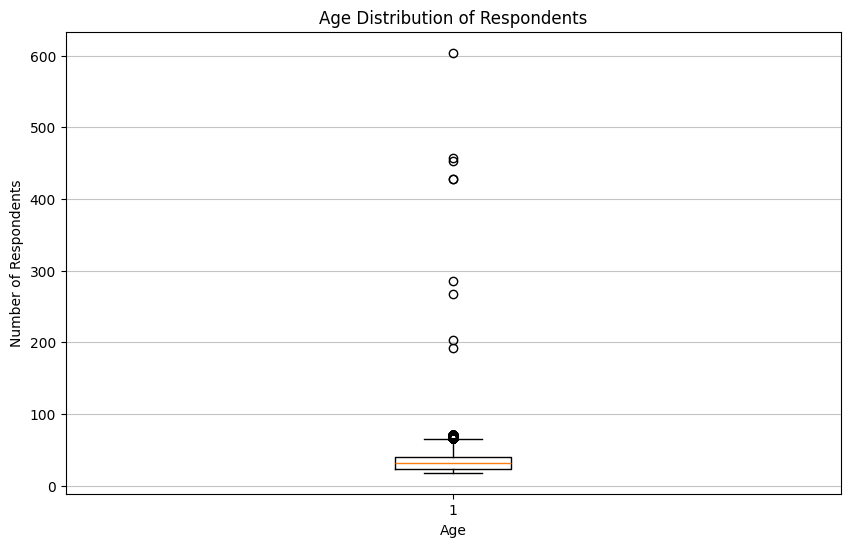

In [7]:
plt.figure(figsize=(10,6))
plt.boxplot(df['age'].dropna())
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Number of Respondents') 
plt.grid(axis='y', alpha=0.75)
plt.show()  

In [8]:
df['age'].max()

np.int64(604)

In [9]:
df[df['age'] > 70]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
3099,R03098,453,M,Metro,Working Professional,26L - 35L,3-4 times,Established,Medium (500 ml),2 to 4,Brand Reputation,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
6262,R06260,428,M,Urban,Entrepreneur,16L - 25L,5-7 times,Established,Large (1 L),above 4,Quality,Exotic,Online,Simple,High (Very health-conscious),Social (eg. Parties),200-250
12403,R12398,604,M,Metro,Retired,<10L,0-2 times,Newcomer,Small (250 ml),2 to 4,Availability,Traditional,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
22549,R22542,457,M,Metro,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
22918,R22911,267,F,Metro,Working Professional,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
24958,R24950,285,M,Semi-Urban,Working Professional,> 35L,0-2 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",150-200
24960,R24952,192,F,Urban,Student,NaN,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
25105,R25096,203,M,Metro,Working Professional,16L - 25L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Retail Store,Premium,High (Very health-conscious),"Active (eg. Sports, gym)",150-200
28770,R28761,428,F,Rural,Working Professional,26L - 35L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),150-200


In [10]:
print(len(df[df['age'] > 100]))
print(len(df[df['age'] > 70]))

9
9


In [11]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound) 

Lower Bound:  -2.5
Upper Bound:  65.5


In [12]:
df = df[df['age'] <= 70]
df.shape

(29991, 17)

**Correct spelling**

In [13]:
columns_list = ['gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range']

In [14]:

unique_values = {col: df[col].unique().tolist() for col in columns_list}
unique_values

{'gender': ['M', 'F'],
 'zone': ['Urban', 'Metro', 'Rural', 'Semi-Urban', 'Metor', 'urbna'],
 'occupation': ['Working Professional', 'Student', 'Entrepreneur', 'Retired'],
 'income_levels': ['<10L',
  '> 35L',
  '16L - 25L',
  nan,
  '10L - 15L',
  '26L - 35L'],
 'consume_frequency(weekly)': ['3-4 times', '5-7 times', '0-2 times', nan],
 'current_brand': ['Newcomer', 'Established', 'newcomer', 'Establishd'],
 'preferable_consumption_size': ['Medium (500 ml)',
  'Large (1 L)',
  'Small (250 ml)'],
 'awareness_of_other_brands': ['0 to 1', '2 to 4', 'above 4'],
 'reasons_for_choosing_brands': ['Price',
  'Quality',
  'Availability',
  'Brand Reputation'],
 'flavor_preference': ['Traditional', 'Exotic'],
 'purchase_channel': ['Online', 'Retail Store', nan],
 'packaging_preference': ['Simple', 'Premium', 'Eco-Friendly'],
 'health_concerns': ['Medium (Moderately health-conscious)',
  'Low (Not very concerned)',
  'High (Very health-conscious)'],
 'typical_consumption_situations': ['Active (e

In [15]:
len(df[df['zone'] == 'Metor'])

4

In [16]:
df['zone'] = df['zone'].replace({'urbna': 'Urban', 'Metor': 'Metro'})
df['current_brand'] = df['current_brand'].replace({'Establishd': 'Established', 'newcomer': 'Newcomer'})


In [17]:
print(df['zone'].unique() )    
print(df['current_brand'].unique())

['Urban' 'Metro' 'Rural' 'Semi-Urban']
['Newcomer' 'Established']


**Handle missing value**

In [18]:
df[df.isna().any(axis=1)]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100
5,R00006,22,F,Urban,Student,NaN,5-7 times,Established,Large (1 L),2 to 4,Price,Traditional,Online,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",100-150
11,R00012,23,F,Urban,Student,NaN,0-2 times,Established,Small (250 ml),0 to 1,Price,Exotic,Retail Store,Premium,Low (Not very concerned),Social (eg. Parties),50-100
14,R00015,22,M,Metro,Student,NaN,3-4 times,Established,Small (250 ml),0 to 1,Price,Traditional,Retail Store,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
20,R00021,23,M,Semi-Urban,Student,NaN,3-4 times,Newcomer,Large (1 L),0 to 1,Availability,Traditional,Retail Store,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,R29986,24,F,Metro,Student,NaN,5-7 times,Newcomer,Small (250 ml),0 to 1,Price,Traditional,Online,Premium,Low (Not very concerned),Social (eg. Parties),100-150
29996,R29987,22,M,Urban,Student,NaN,0-2 times,Established,Small (250 ml),0 to 1,Price,Exotic,Online,Premium,Low (Not very concerned),Social (eg. Parties),50-100
29999,R29990,23,F,Metro,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
30002,R29993,18,M,Metro,Student,NaN,0-2 times,Established,Medium (500 ml),2 to 4,Availability,Exotic,Online,Premium,Low (Not very concerned),Social (eg. Parties),100-150


In [19]:
df.isna().sum() 

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [20]:
print(df['consume_frequency(weekly)'].mode()[0])
print(df['purchase_channel'].mode()[0])

3-4 times
Online


In [21]:
df['consume_frequency(weekly)'] = df['consume_frequency(weekly)'].fillna(df['consume_frequency(weekly)'].mode()[0])
df['purchase_channel'] = df['purchase_channel'].fillna(df['purchase_channel'].mode()[0])
df.isna().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            0
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                     0
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [22]:
missing_df = df[["zone","occupation","income_levels","price_range"]]
missing_df.head(10)

,zone,occupation,income_levels,price_range
0,Urban,Working Professional,<10L,100-150
1,Metro,Working Professional,> 35L,200-250
2,Rural,Working Professional,> 35L,200-250
3,Urban,Working Professional,16L - 25L,150-200
4,Metro,Student,NaN,50-100
5,Urban,Student,NaN,100-150
6,Urban,Entrepreneur,10L - 15L,200-250
7,Urban,Entrepreneur,26L - 35L,200-250
8,Semi-Urban,Working Professional,<10L,100-150
9,Semi-Urban,Entrepreneur,10L - 15L,200-250


In [23]:
df['income_levels'] = df['income_levels'].fillna('Not Reported')
df.isna().sum()

respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

In [24]:
# cleaned_df = df.copy()
# cleaned_df.to_csv('cleaned_survey_results.csv', index=False)

# Feature Engineering

In [25]:
new_df = pd.read_csv('resources/cleaned_survey_results.csv')
new_df.shape

(29991, 17)

In [26]:
new_df.isna().sum()

respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

**Step 1: Categorize Age into Age Groups**

In [27]:
def categorize_age(age):
    if 18 <= age <= 25:
        return '18-25'
    elif 26 <= age <= 35:
        return '26-35'
    elif 36 <= age <= 45:
        return '36-45'
    elif 46 <= age <= 55:
        return '46-55'
    elif 56 <= age <= 70:
        return '56-70'
    else:
        return '70+'

In [28]:
new_df['age'] = new_df['age'].apply(categorize_age)
new_df['age'].value_counts()

age
18-25    10468
26-35     9093
36-45     5972
46-55     2966
56-70     1492
Name: count, dtype: int64

**Step 2: Create `cf_ab_score` (Consume Frequency and Awareness Brand
Score)**

In [29]:
new_df['consume_frequency(weekly)'].value_counts()

consume_frequency(weekly)
3-4 times    11794
5-7 times     9774
0-2 times     8423
Name: count, dtype: int64

In [30]:
def fequency_score(freq):
    if freq == '0-2 times':
        return 1
    elif freq == '3-4 times':
        return 2
    else:
        return 3
new_df['frequency_score'] = new_df['consume_frequency(weekly)'].apply(fequency_score)
new_df[['consume_frequency(weekly)', 'frequency_score']].head(10)

,consume_frequency(weekly),frequency_score
0,3-4 times,2
1,5-7 times,3
2,3-4 times,2
3,5-7 times,3
4,3-4 times,2
5,5-7 times,3
6,5-7 times,3
7,5-7 times,3
8,5-7 times,3
9,5-7 times,3


In [31]:
new_df['awareness_of_other_brands'].value_counts()

awareness_of_other_brands
0 to 1     12966
2 to 4     11225
above 4     5800
Name: count, dtype: int64

In [32]:
def awareness_score(awareness):
    if awareness == '0 to 1':
        return 1
    elif awareness == '2 to 4':
        return 2
    elif awareness == 'above 4':
        return 3
new_df['awareness_score'] = new_df['awareness_of_other_brands'].apply(awareness_score)
new_df[['awareness_of_other_brands', 'awareness_score']].head(10)

,awareness_of_other_brands,awareness_score
0,0 to 1,1
1,2 to 4,2
2,2 to 4,2
3,0 to 1,1
4,0 to 1,1
5,2 to 4,2
6,2 to 4,2
7,above 4,3
8,2 to 4,2
9,2 to 4,2


In [33]:
cf_ab_score = new_df['frequency_score'] / (new_df['awareness_score'] + new_df['frequency_score'])
new_df['cf_ab_score'] = round(cf_ab_score, 2)
new_df['cf_ab_score'].max()


np.float64(0.75)

**Step 3: Create Zone Affluence Score (ZAS)**

In [34]:
df['zone'].value_counts()


zone
Metro         11910
Urban         10691
Semi-Urban     5274
Rural          2116
Name: count, dtype: int64

In [35]:
def zone_map(zone):
    if zone == 'Urban':
        return 3
    elif zone == 'Metro':
        return 4
    elif zone == 'Rural':
        return 1
    elif zone == 'Semi-Urban':
        return 2
new_df['zone_score'] = new_df['zone'].apply(zone_map)
new_df[['zone', 'zone_score']].head(10)

,zone,zone_score
0,Urban,3
1,Metro,4
2,Rural,1
3,Urban,3
4,Metro,4
5,Urban,3
6,Urban,3
7,Urban,3
8,Semi-Urban,2
9,Semi-Urban,2


In [36]:
df['income_levels'].value_counts()  

income_levels
Not Reported    8060
16L - 25L       5897
10L - 15L       5251
<10L            4661
26L - 35L       3872
> 35L           2250
Name: count, dtype: int64

In [37]:
def categorize_income_levels(income):
    if income == 'Not Reported':
        return 0
    elif income == '16L - 25L':
        return 3
    elif income == '10L - 15L':
        return 2
    elif income == '<10L':
        return 1
    elif income == '26L - 35L':
        return 4
    elif income == '> 35L':
        return 5
new_df['income_level_score'] = new_df['income_levels'].apply(categorize_income_levels)
new_df[['income_levels', 'income_level_score']].head(10)    

,income_levels,income_level_score
0,<10L,1
1,> 35L,5
2,> 35L,5
3,16L - 25L,3
4,Not Reported,0
5,Not Reported,0
6,10L - 15L,2
7,26L - 35L,4
8,<10L,1
9,10L - 15L,2


In [38]:
new_df['zas_score'] = new_df['zone_score'] * new_df['income_level_score']
len(new_df['zas_score'].unique())

14

**Step 4: Brand Switching Indicator (BSI)**

In [39]:
new_df['bsi'] = (
    ((new_df['current_brand'] != 'Established') & 
     (new_df['reasons_for_choosing_brands'].isin(['Price', 'Quality'])))
    .astype(int)
)
new_df[['bsi','reasons_for_choosing_brands','current_brand']].head(10)

,bsi,reasons_for_choosing_brands,current_brand
0,1,Price,Newcomer
1,0,Quality,Established
2,0,Availability,Newcomer
3,0,Brand Reputation,Newcomer
4,0,Availability,Established
5,0,Price,Established
6,1,Price,Newcomer
7,0,Brand Reputation,Established
8,0,Availability,Newcomer
9,1,Price,Newcomer


In [40]:
occupation_age_table = pd.crosstab(new_df['age'], new_df['occupation'])
print(occupation_age_table)

occupation  Entrepreneur  Retired  Student  Working Professional
age                                                             
18-25                535        0     7328                  2605
26-35               1826        0      697                  6570
36-45               1619        0        0                  4353
46-55                799        0        0                  2167
56-70                221     1130       35                   106


In [41]:
new_df = new_df.drop(
    new_df[(new_df['age'] == '56-70') & (new_df['occupation'] == 'Student')].index
)

new_df.shape

(29956, 24)

In [42]:
new_df.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,health_concerns,typical_consumption_situations,price_range,frequency_score,awareness_score,cf_ab_score,zone_score,income_level_score,zas_score,bsi
0,R00001,26-35,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,...,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,2,1,0.67,3,1,3,1
1,R00002,46-55,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,...,Medium (Moderately health-conscious),Social (eg. Parties),200-250,3,2,0.60,4,5,20,0
2,R00003,36-45,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,...,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,2,2,0.50,1,5,5,0
3,R00004,26-35,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,...,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,3,1,0.75,3,3,9,0
4,R00005,18-25,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,...,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,2,1,0.67,4,0,0,0


In [43]:
len(new_df[new_df['bsi'] == 0])

20796

# Modeling

In [44]:
from sklearn.model_selection import train_test_split

**Prepare Feature and Target Variables**

In [45]:
new_df.shape

(29956, 24)

In [46]:
X = new_df.drop(columns=['respondent_id', 'price_range'])
y = new_df['price_range']

**Data Splitting**

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("X_train shape",X_train.shape)
print("X_test shape",X_test.shape)
print("y_train shape",y_train.shape)
print("y_test shape",y_test.shape)


X_train shape (22467, 22)
X_test shape (7489, 22)
y_train shape (22467,)
y_test shape (7489,)


In [48]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)

Train DataFrame shape: (22467, 23)
Test DataFrame shape: (7489, 23)


**Feature Encoding**

In [49]:
categorical_cols = X.select_dtypes(include=['object','category']).columns
numberical_cols = X.select_dtypes(exclude=['object','category']).columns
print("Categorical columns:", categorical_cols.tolist())
print("Number of Categorical columns:", len(categorical_cols.tolist()))
print("Numberical columns:", numberical_cols.tolist())
print("Number of Numberical columns:", len(numberical_cols.tolist()))

Categorical columns: ['age', 'gender', 'zone', 'occupation', 'income_levels', 'consume_frequency(weekly)', 'current_brand', 'preferable_consumption_size', 'awareness_of_other_brands', 'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel', 'packaging_preference', 'health_concerns', 'typical_consumption_situations']
Number of Categorical columns: 15
Numberical columns: ['frequency_score', 'awareness_score', 'cf_ab_score', 'zone_score', 'income_level_score', 'zas_score', 'bsi']
Number of Numberical columns: 7


In [50]:
from sklearn.preprocessing import LabelEncoder

**Level Encoding**

In [51]:
level_encoding_cols = ['age', 'income_levels', 'health_concerns', 'consume_frequency(weekly)', 'preferable_consumption_size', 'price_range']
le = LabelEncoder()
for col in level_encoding_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])


In [52]:
train_df.head()

,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,...,health_concerns,typical_consumption_situations,frequency_score,awareness_score,cf_ab_score,zone_score,income_level_score,zas_score,bsi,price_range
8385,0,F,Semi-Urban,Working Professional,0,0,Newcomer,2,above 4,Availability,...,1,Social (eg. Parties),1,3,0.25,2,2,4,0,3
26377,0,F,Urban,Working Professional,1,2,Established,1,2 to 4,Quality,...,2,Social (eg. Parties),3,2,0.60,3,3,9,0,2
11269,0,F,Urban,Student,5,1,Newcomer,2,2 to 4,Price,...,2,"Active (eg. Sports, gym)",2,2,0.50,3,0,0,1,0
9103,1,M,Metro,Working Professional,1,1,Established,0,2 to 4,Quality,...,1,"Active (eg. Sports, gym)",2,2,0.50,4,3,12,0,1
3370,1,M,Metro,Entrepreneur,1,0,Established,0,above 4,Brand Reputation,...,2,Casual (eg. At home),1,3,0.25,4,3,12,0,1


**One-Hot Encoding**

In [53]:
# one_hot_encoded.shape
one_hot_encoded_cols = [col for col in categorical_cols.tolist() if col not in level_encoding_cols]


train_df = pd.get_dummies(train_df, columns=one_hot_encoded_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=one_hot_encoded_cols, drop_first=True)


In [54]:
train_df.head()

,age,income_levels,consume_frequency(weekly),preferable_consumption_size,health_concerns,frequency_score,awareness_score,cf_ab_score,zone_score,income_level_score,...,awareness_of_other_brands_above 4,reasons_for_choosing_brands_Brand Reputation,reasons_for_choosing_brands_Price,reasons_for_choosing_brands_Quality,flavor_preference_Traditional,purchase_channel_Retail Store,packaging_preference_Premium,packaging_preference_Simple,typical_consumption_situations_Casual (eg. At home),typical_consumption_situations_Social (eg. Parties)
8385,0,0,0,2,1,1,3,0.25,2,2,...,True,False,False,False,True,False,False,True,False,True
26377,0,1,2,1,2,3,2,0.60,3,3,...,False,False,False,True,True,False,True,False,False,True
11269,0,5,1,2,2,2,2,0.50,3,0,...,False,False,True,False,True,False,False,True,False,False
9103,1,1,1,0,1,2,2,0.50,4,3,...,False,False,False,True,True,False,True,False,False,False
3370,1,1,0,0,2,1,3,0.25,4,3,...,True,True,False,False,True,False,False,False,True,False


In [55]:
test_df.head()

,age,income_levels,consume_frequency(weekly),preferable_consumption_size,health_concerns,frequency_score,awareness_score,cf_ab_score,zone_score,income_level_score,...,awareness_of_other_brands_above 4,reasons_for_choosing_brands_Brand Reputation,reasons_for_choosing_brands_Price,reasons_for_choosing_brands_Quality,flavor_preference_Traditional,purchase_channel_Retail Store,packaging_preference_Premium,packaging_preference_Simple,typical_consumption_situations_Casual (eg. At home),typical_consumption_situations_Social (eg. Parties)
11973,0,5,2,0,2,3,1,0.75,3,0,...,False,False,True,False,False,False,False,True,False,True
1805,0,0,0,2,0,1,3,0.25,4,2,...,True,False,True,False,False,False,False,True,False,False
517,1,1,0,1,2,1,3,0.25,4,3,...,True,True,False,False,False,True,True,False,False,False
3817,3,1,2,1,2,3,2,0.60,4,3,...,False,False,False,True,True,True,True,False,False,False
28607,2,2,2,1,0,3,1,0.75,4,4,...,False,False,False,True,False,False,True,False,True,False


**Model Selection:**

In [56]:
# ML imports
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb
import lightgbm as lgb

In [57]:
# Define features and target
X_train = train_df.drop(columns=["price_range"])  # replace with your actual target
y_train = train_df["price_range"]

X_test = test_df.drop(columns=["price_range"])
y_test = test_df["price_range"]

print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())




Train: price_range
2    7281
1    6574
0    5863
3    2749
Name: count, dtype: int64
Test: price_range
2    2430
1    2223
0    1930
3     906
Name: count, dtype: int64


In [ ]:
# Dictionary of models
models = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(),
    "SVM": SVC(kernel="linear", probability=True),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier()
}

best_model_name = None
best_accuracy = 0
best_model = None

# Train and evaluate each model
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

    print(f"✅ Accuracy of {name}: {acc:.4f}")
    print(f"📊 Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

print(f"Best Model: {best_model_name} with accuracy: {best_accuracy:.4f}")


🔹 Training GaussianNB...
✅ Accuracy of GaussianNB: 0.5825
📊 Classification Report for GaussianNB:

              precision    recall  f1-score   support

           0       0.47      0.30      0.36      1930
           1       0.57      0.39      0.46      2223
           2       0.72      0.87      0.79      2430
           3       0.45      0.90      0.60       906

    accuracy                           0.58      7489
   macro avg       0.55      0.61      0.55      7489
weighted avg       0.58      0.58      0.56      7489

------------------------------------------------------------
Best Model: GaussianNB with accuracy: 0.5825

🔹 Training LogisticRegression...


/opt/anaconda3/envs/exp_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Accuracy of LogisticRegression: 0.8044
📊 Classification Report for LogisticRegression:

              precision    recall  f1-score   support

           0       0.74      0.76      0.75      1930
           1       0.76      0.78      0.77      2223
           2       0.91      0.89      0.90      2430
           3       0.79      0.72      0.75       906

    accuracy                           0.80      7489
   macro avg       0.80      0.79      0.79      7489
weighted avg       0.81      0.80      0.80      7489

------------------------------------------------------------
Best Model: LogisticRegression with accuracy: 0.8044

🔹 Training SVM...
✅ Accuracy of SVM: 0.8117
📊 Classification Report for SVM:

              precision    recall  f1-score   support

           0       0.75      0.76      0.76      1930
           1       0.77      0.78      0.78      2223
           2       0.91      0.90      0.90      2430
           3       0.79      0.75      0.77       906

    accura

# MLFlow Deployment and Dagshub Publishing

In [59]:
import mlflow
from sklearn.metrics import accuracy_score, classification_report
import dagshub

In [60]:

dagshub.init(repo_owner='Aadarsh4u-code', repo_name='Survey-price-range-prediction', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow")
mlflow.set_experiment("survey_price_range_classification")

models = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear", probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier()
}

Accessing as Aadarsh4u-code

Initialized MLflow to track repo "Aadarsh4u-code/Survey-price-range-prediction"

Repository Aadarsh4u-code/Survey-price-range-prediction initialized!

In [61]:
best_model_name = None
best_accuracy = 0
best_model = None

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Log metrics
        acc = accuracy_score(y_test, y_pred)
        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model
            best_model_name = name
        mlflow.log_metric("accuracy", acc)
        
        # Optionally log more metrics like F1, precision, recall
        report = classification_report(y_test, y_pred, output_dict=True)
        mlflow.log_metric("precision_macro", report["macro avg"]["precision"])
        mlflow.log_metric("recall_macro", report["macro avg"]["recall"])
        mlflow.log_metric("f1_macro", report["macro avg"]["f1-score"])
        
        # Log model
        mlflow.sklearn.log_model(model, "model")

        print(f"Logged {name} with accuracy: {acc:.4f}")

2025/09/27 21:50:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged GaussianNB with accuracy: 0.5825
🏃 View run GaussianNB at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0/runs/cf3f66222e31453fb736259280a76ffb
🧪 View experiment at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0


2025/09/27 21:50:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged LogisticRegression with accuracy: 0.8100
🏃 View run LogisticRegression at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0/runs/9cb54ba7c1dd491fa47e2c5dd365cd73
🧪 View experiment at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0


2025/09/27 21:51:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

Logged RandomForest with accuracy: 0.8996
🏃 View run RandomForest at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0/runs/707b16394fa14ef89a7275dc7d4d8559
🧪 View experiment at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0


/opt/anaconda3/envs/exp_venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:52:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2025/09/27 21:52:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged XGBoost with accuracy: 0.9263
🏃 View run XGBoost at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0/runs/2eea524fc3a84679a1d9b2c6851a5e0d
🧪 View experiment at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 101
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 31
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
[LightGBM] [Info] Start training from score -2.100810


2025/09/27 21:52:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged LightGBM with accuracy: 0.9248
🏃 View run LightGBM at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0/runs/6e96a2e776874f6fa1a25d2429ee39ca
🧪 View experiment at: https://dagshub.com/Aadarsh4u-code/Survey-price-range-prediction.mlflow/#/experiments/0


In [62]:
# Save the model
import joblib

# Save
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']